# Car Price Prediction Project
## End-to-End Training Notebook (Flask Compatible)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## Download Dataset

In [2]:
import os
import urllib.request

download_dir = "./data/"
download_url = "https://raw.githubusercontent.com/manishkr1754/CarDekho_Used_Car_Price_Prediction/main/notebooks/data/cardekho_dataset.csv"

os.makedirs(download_dir, exist_ok=True)

filename = os.path.basename(download_url)
download_file_path = os.path.join(download_dir, filename)

urllib.request.urlretrieve(download_url, download_file_path)

print("Downloaded at:", download_file_path)

Downloaded at: ./data/cardekho_dataset.csv


## Load Dataset

In [3]:
df = pd.read_csv("data/cardekho_dataset.csv")
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


## Dataset Overview

In [4]:
print(df.shape)
df.info()
df.describe()

(15411, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


## Keep Only Flask Features

In [5]:
features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats',
    'seller_type',
    'fuel_type',
    'transmission_type'
]

df = df[features + ['selling_price']]

## Missing Values

In [6]:
df.isnull().sum()
df.dropna(inplace=True)

## Feature Separation

In [7]:
numerical_features = df.select_dtypes(exclude='object').columns
categorical_features = df.select_dtypes(include='object').columns

## Univariate Analysis

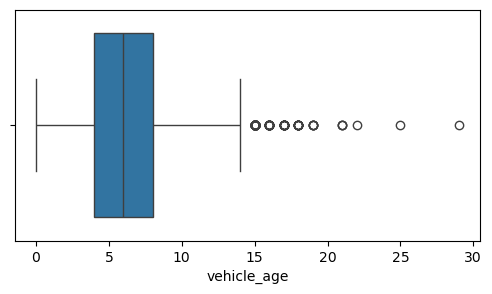

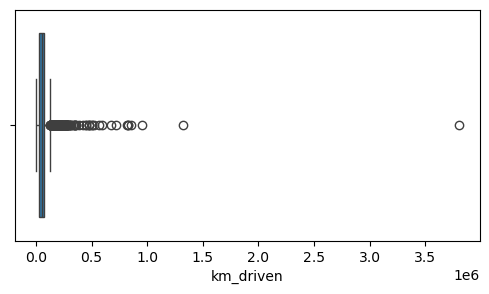

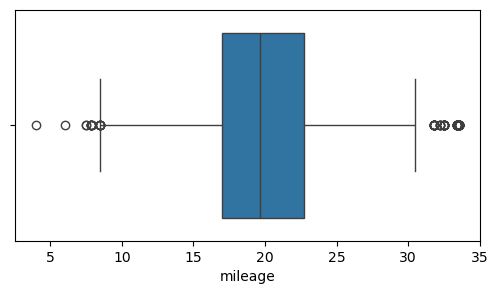

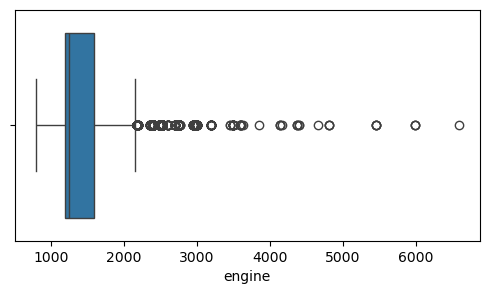

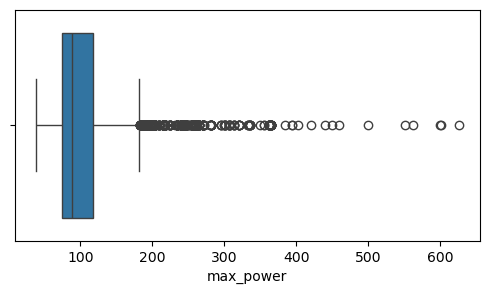

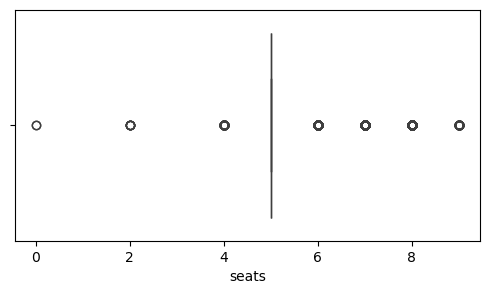

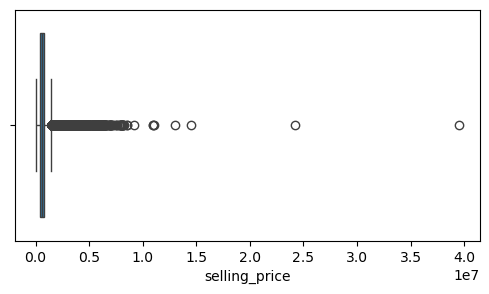

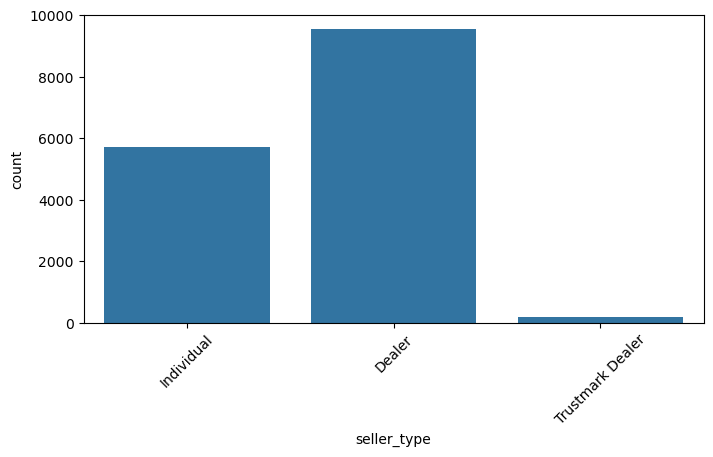

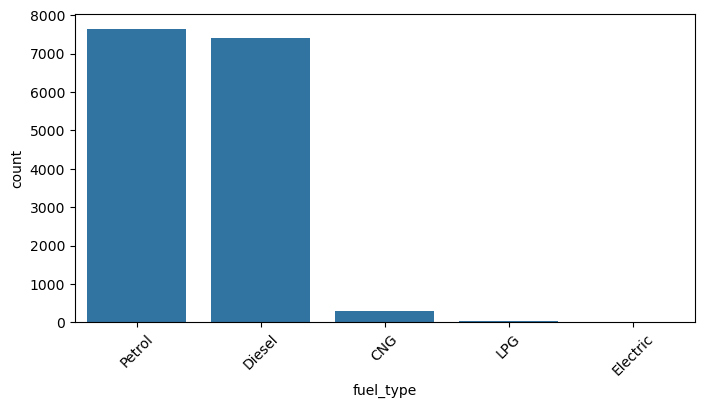

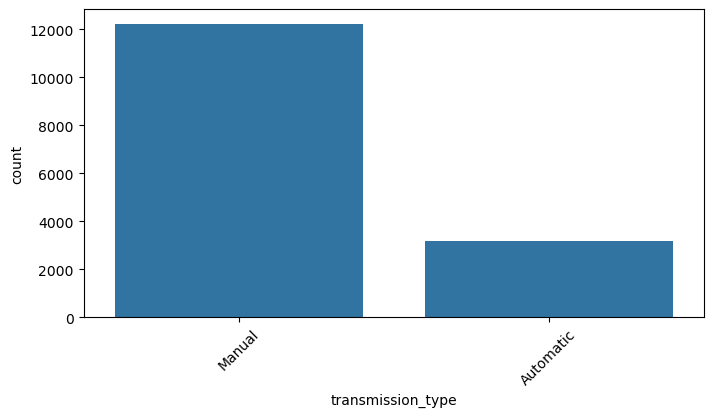

In [8]:
for col in numerical_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.show()

for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()

## Bivariate Analysis

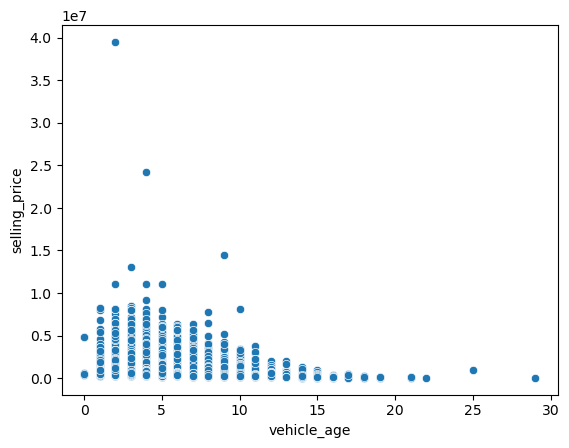

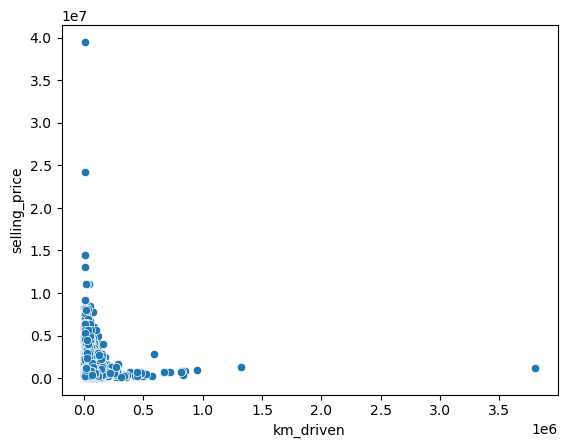

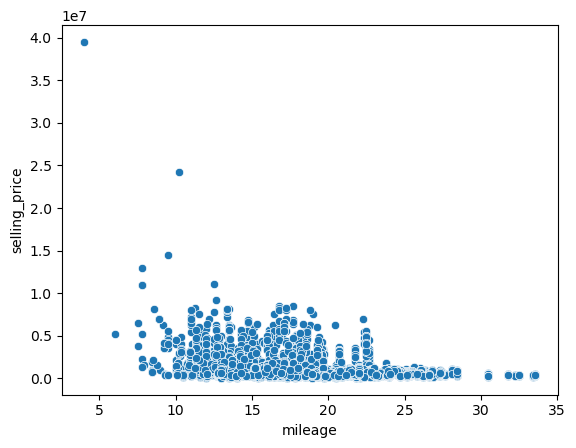

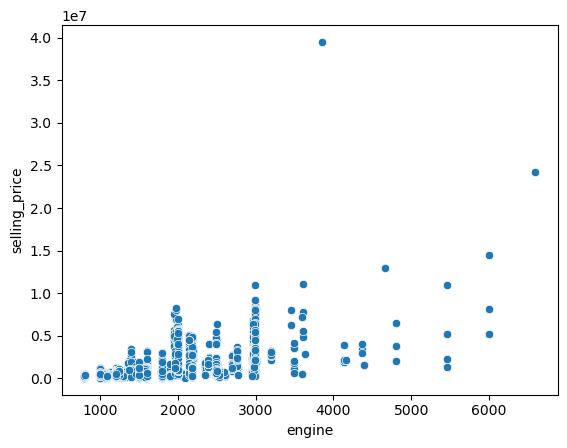

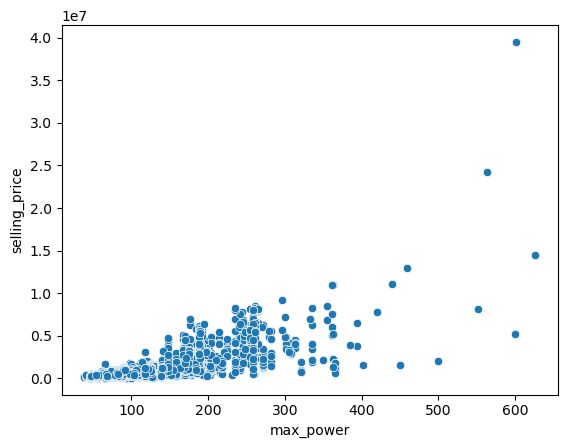

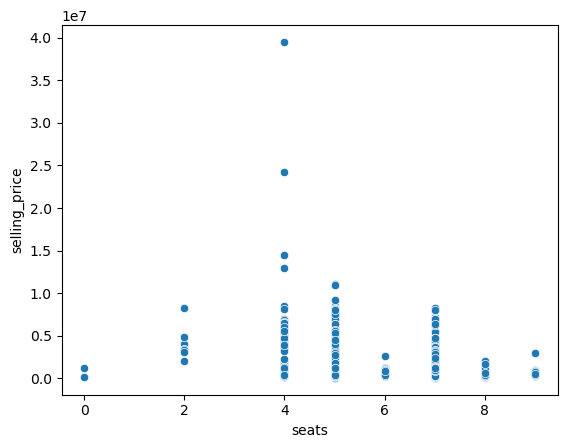

In [9]:
for col in numerical_features:
    if col != 'selling_price':
        sns.scatterplot(x=df[col], y=df['selling_price'])
        plt.show()

## Correlation Heatmap

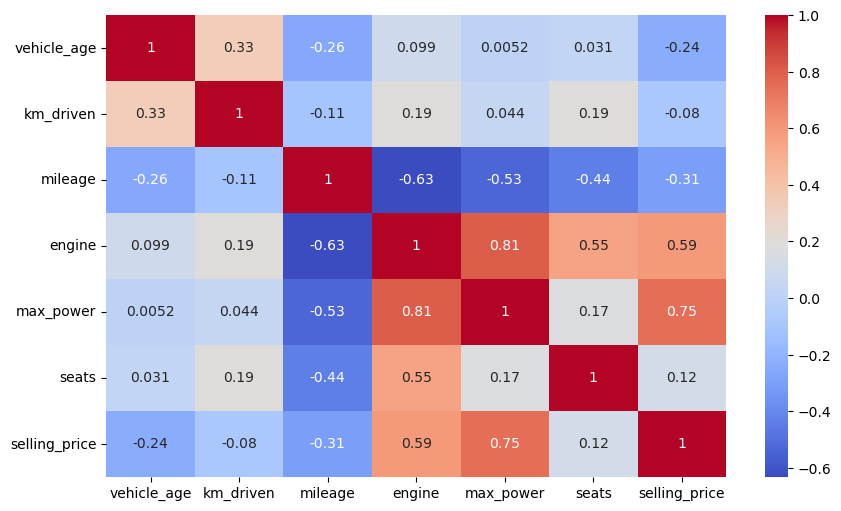

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

## Outlier Removal

In [11]:
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

for col in numerical_features:
    if col != 'selling_price':
        df = remove_outliers(df, col)

## Encoding

In [12]:
df = pd.get_dummies(df, drop_first=True)

## Create X and y

In [13]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

print(X.columns.tolist())
print(X.shape)

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual']
(11321, 12)


## Save Feature Columns

In [14]:
import pickle
pickle.dump(X.columns.tolist(), open('columns.pkl', 'wb'))

## Train Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Baseline Random Forest

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Baseline Evaluation

In [17]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pred_rf = rf.predict(X_test)

print("R2:", r2_score(y_test, pred_rf))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

R2: 0.8819352998504966
MAE: 63083.915577040076
RMSE: 90677.37023354272


## Hyperparameter Tuning

In [18]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_tuned = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=params,
    n_iter=5,
    cv=3,
    verbose=2,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [None, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,n_iter,5
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


## Final Evaluation

In [19]:
best_model = rf_tuned.best_estimator_

y_pred = best_model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8862792801702151
MAE: 61712.6428973079
RMSE: 88993.58092860425


## Save Final Model

In [20]:
pickle.dump(best_model, open('car_price_model.pkl', 'wb'))
print("Model Saved Successfully")

Model Saved Successfully


In [21]:
print(X.columns.tolist())

['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual']
